In [1]:
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=True)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_8K_pbmc_citeseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(
    f"{dataset}/data.zarr",
    default_assay="RNA",
    nthreads=4,
)

Downloading bucket files: 47825114 / 47825114 complete

Downloading bytes: 47825114 / 47825114 complete

In [2]:
integrated = []
for ref in ds.list_artifacts(scope="datastore", kind="integrated_graph"):
    status = ds.inspect_artifact(ref)
    integrated.append(
        {
            "label": status.execution_options["label"],
            "method": status.parameters["method"],
            "artifact": ref.artifact_id[:12],
        }
    )
pd.DataFrame(integrated).sort_values("label", ignore_index=True)

,label,method,artifact
0,RNA+ADT,snn,e03b88d949a8
1,RNA+ADT_wnn,wnn,1aa834b3fc11


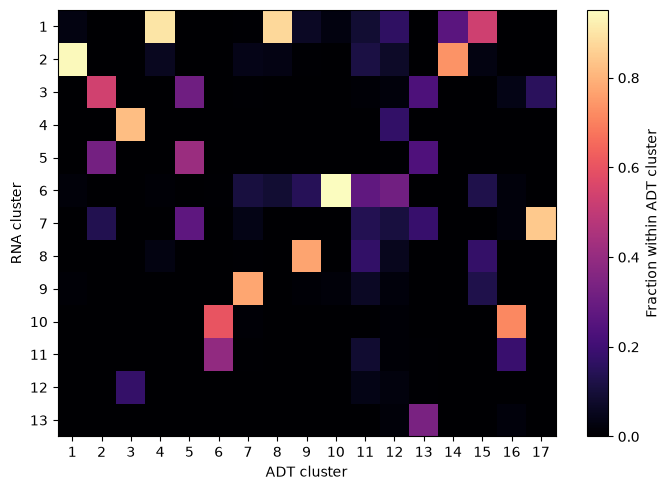

In [3]:
overlap = pd.crosstab(
    ds.cells.fetch("RNA_leiden_cluster"),
    ds.cells.fetch("ADT_leiden_cluster"),
    normalize="columns",
)

fig, ax = plt.subplots(figsize=(7, 5))
image = ax.imshow(overlap.to_numpy(), aspect="auto", cmap="magma")
ax.set(
    xlabel="ADT cluster",
    ylabel="RNA cluster",
    xticks=np.arange(overlap.shape[1]),
    yticks=np.arange(overlap.shape[0]),
    xticklabels=overlap.columns,
    yticklabels=overlap.index,
)
fig.colorbar(image, ax=ax, label="Fraction within ADT cluster")
fig.tight_layout()

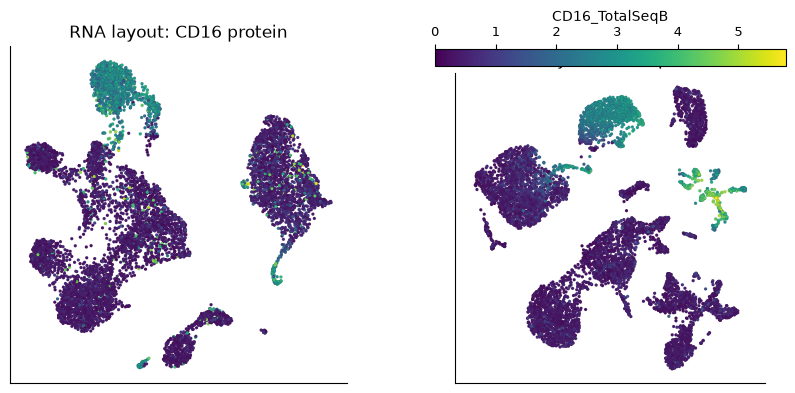

In [4]:
def compare_signal(feature, assay, label):
    figure, axes = plt.subplots(1, 2, figsize=(9, 4))
    for index, (axis, (layout_label, layout_key)) in enumerate(
        zip(
            axes,
            (("RNA layout", "RNA_UMAP"), ("ADT layout", "ADT_UMAP")),
            strict=True,
        )
    ):
        ds.plots.embedding(
            layout_key=layout_key,
            color_by=feature,
            from_assay=assay,
            point_size=5,
            show_legend=index == 1,
            show_titles=False,
            target=axis,
            show=False,
        )
        axis.set_title(f"{layout_label}: {label}")
    figure.tight_layout()
    return figure


compare_signal("CD16_TotalSeqB", "ADT", "CD16 protein");

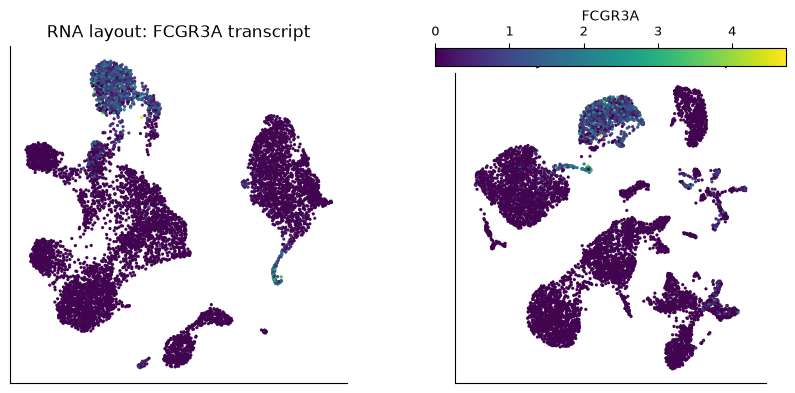

In [5]:
compare_signal("FCGR3A", "RNA", "FCGR3A transcript");

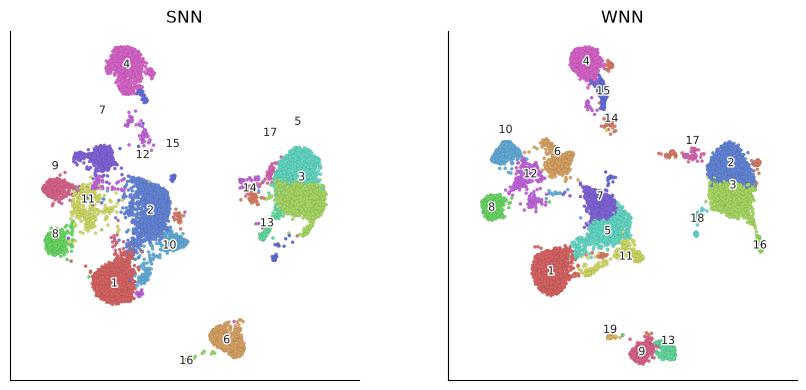

In [6]:
figure, axes = plt.subplots(1, 2, figsize=(9, 4))
integration_panels = (
    ("SNN", "RNA+ADT_UMAP", "RNA+ADT_leiden_cluster"),
    ("WNN", "RNA+ADT_wnn_UMAP", "RNA+ADT_wnn_leiden_cluster"),
)
for axis, (title, layout_key, color_by) in zip(
    axes, integration_panels, strict=True
):
    ds.plots.embedding(
        layout_key=layout_key,
        color_by=color_by,
        legend_loc="on_data",
        show_titles=False,
        target=axis,
        show=False,
    )
    axis.set_title(title)
figure.tight_layout()

In [7]:
partition_columns = {
    "RNA": "RNA_leiden_cluster",
    "ADT": "ADT_leiden_cluster",
    "SNN": "RNA+ADT_leiden_cluster",
    "WNN": "RNA+ADT_wnn_leiden_cluster",
}
concordance_rows = []
for first, second in combinations(partition_columns, 2):
    columns = [
        partition_columns[first],
        partition_columns[second],
    ]
    concordance_rows.append(
        {
            "comparison": f"{first} vs {second}",
            "ARI": ds.metric_label_concordance(
                columns,
                metric="ari",
            ),
            "NMI": ds.metric_label_concordance(
                columns,
                metric="nmi",
            ),
        }
    )
pd.DataFrame(concordance_rows)

,comparison,ARI,NMI
0,RNA vs ADT,0.553244,0.665044
1,RNA vs SNN,0.651288,0.731688
2,RNA vs WNN,0.652083,0.760625
3,ADT vs SNN,0.710219,0.790859
4,ADT vs WNN,0.653095,0.755387
5,SNN vs WNN,0.763193,0.833843


In [8]:
weight_columns = {
    "RNA weight": "RNA+ADT_wnn_RNA_weight",
    "ADT weight": "RNA+ADT_wnn_ADT_weight",
}
weight_frame = pd.DataFrame(
    {
        label: ds.cells.fetch(column, key="I")
        for label, column in weight_columns.items()
    }
)
weight_values = weight_frame.to_numpy(dtype=np.float64)
pd.Series(
    {
        "all finite": bool(np.isfinite(weight_values).all()),
        "all non-negative": bool((weight_values >= 0).all()),
        "maximum row-sum error": float(
            np.max(np.abs(weight_values.sum(axis=1) - 1))
        ),
    }
)

all finite               True
all non-negative         True
maximum row-sum error     0.0
dtype: object

In [9]:
rna_clusters = pd.Series(
    ds.cells.fetch("RNA_leiden_cluster", key="I")
)
adt_clusters = pd.Series(
    ds.cells.fetch("ADT_leiden_cluster", key="I")
)
dominant_rna_by_adt = overlap.idxmax(axis=0)
weight_frame["RNA-ADT overlap"] = np.where(
    rna_clusters == adt_clusters.map(dominant_rna_by_adt),
    "dominant overlap",
    "other overlap",
)
weight_frame.groupby("RNA-ADT overlap")[
    list(weight_columns)
].agg(["count", "mean", "median"])

RNA weight                    ADT weight                   
                      count      mean   median      count      mean   median
RNA-ADT overlap                                                             
dominant overlap       5255  0.511463  0.52063       5255  0.488537  0.47937
other overlap          2144  0.486138  0.44787       2144  0.513862  0.55213